# Adversarial Attacks on Post-hoc Explainability Methods

We reimplement [Fooling LIME and SHAP: Adversarial Attacks on Post-hoc Explainability Methods](https://github.com/dylan-slack/Fooling-LIME-SHAP/tree/master).

One important consideration is going to be how we implement Local ALE for classification. We should think carefully about the specific model being learned.

In [17]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

from utils import Explanation
from ale import ALE
from shap import SHAP

In [18]:
def get_and_clean_compas_data():
	"""
    Handle processing of COMPAS according to: https://github.com/propublica/compas-analysis
	"""
	PROTECTED_CLASS = 1
	POSITIVE_OUTCOME = 0
	NEGATIVE_OUTCOME = 1

	compas_df = pd.read_csv("data/compas.csv", index_col=0)

    # replicate data cleaning from original COMPAS analysis
	compas_df = compas_df.loc[(compas_df['days_b_screening_arrest'] <= 30) &
							  (compas_df['days_b_screening_arrest'] >= -30) &
							  (compas_df['is_recid'] != -1) &
							  (compas_df['c_charge_degree'] != "O") &
							  (compas_df['score_text'] != "NA")]
	compas_df['length_of_stay'] = (pd.to_datetime(compas_df['c_jail_out']) - pd.to_datetime(compas_df['c_jail_in'])).dt.days

    # reduce number of columns
	X = compas_df[['age', 'two_year_recid', 'c_charge_degree', 'race', 'sex', 'priors_count', 'length_of_stay']]

	# high scores (higher risk of recidivism) leads to negative outcomes
	y = np.array([NEGATIVE_OUTCOME if score == 'High' else POSITIVE_OUTCOME for score in compas_df['score_text']])
	sens = X.pop('race')

	# assign African-American as the protected class
	X = pd.get_dummies(X)
	sensitive_attr = np.array(pd.get_dummies(sens).pop('African-American'))
	X['is_african_american'] = sensitive_attr

	# make sure everything is lining up
	assert all((sens == 'African-American') == (X['is_african_american'] == PROTECTED_CLASS))
	
	return X, y

In [19]:
X_compas, y_compas = get_and_clean_compas_data()

## PCA Experiment

We show that the perturbations created by ALE are in some sense "milder" than the ones created by LIME and KernelSHAP.

In [20]:
def plot_2d_compas_pca(X_compas, explainer_class: Explanation, explain_n=100):
    # only take numerical features
    X_numerical = X_compas[["age", "priors_count", "length_of_stay"]].to_numpy()
    dummy_f = lambda x: x
    explainer = explainer_class(dummy_f, X_numerical, verbose=False)
    if isinstance(explainer, ALE):
        explainer.explain()
    for i in range(explain_n):
        explainer.explain_local(X_numerical[i, :])
    X_perturbed = explainer.get_query_points()
    print(X_numerical.shape, X_perturbed.shape)

    all_x = np.vstack((X_perturbed, X_numerical))
    pca = PCA(n_components=2)
    results = pca.fit_transform(all_x)

    # plot all original and perturbed data points
    plt.scatter(results[:X_perturbed.shape[0], 0], results[:X_perturbed.shape[0], 1], alpha=.1, color='red', label='Perturbed Data')
    plt.scatter(results[-X_numerical.shape[0]:, 0], results[-X_numerical.shape[0]:, 1], alpha=.1, color='blue', label='Original Data')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.title(f'PCA of Original and Perturbed Data using {explainer_class.__name__}')
    plt.legend()
    plt.show()


In [21]:
X_compas[["age", "priors_count", "length_of_stay"]].describe()

,age,priors_count,length_of_stay
count,6172.000000,6172.000000,6172.000000
mean,34.534511,3.246436,14.622813
std,11.730938,4.743770,46.693528
min,18.000000,0.000000,-1.000000
25%,25.000000,0.000000,0.000000
50%,31.000000,1.000000,1.000000
75%,42.000000,4.000000,5.000000
max,96.000000,38.000000,799.000000


In [67]:
print("Correlation matrix for numerical features:")
np.corrcoef(X_compas[["age", "priors_count", "length_of_stay"]].to_numpy(), rowvar=False)

Correlation matrix for numerical features:


array([[1.        , 0.1197726 , 0.01164461],
       [0.1197726 , 1.        , 0.18905425],
       [0.01164461, 0.18905425, 1.        ]])

/Users/dawsonren/Desktop/Experiments/ExplainableML/ale/tree_partitioning.py:290: UserWarning: generate_connected_delta_values: all features flat, splitting on first variable
  warnings.warn(


(6172, 3) (8055, 3)


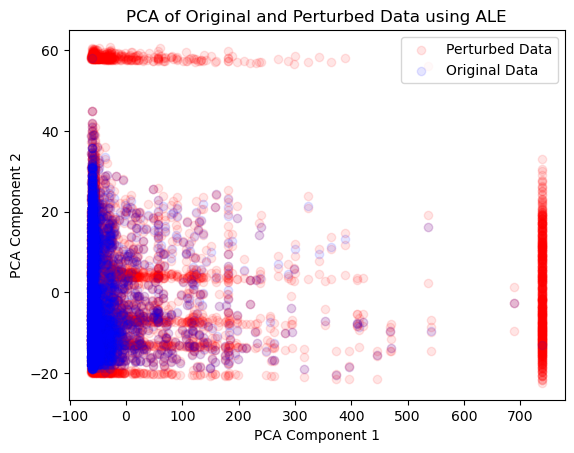

In [22]:
plot_2d_compas_pca(X_compas, ALE, explain_n=10)

Explanation of large components: "length_of_stay" goes to the max observed, and so those points are obviously perturbed. Same for "priors_count"

(6172, 3) (38978, 3)


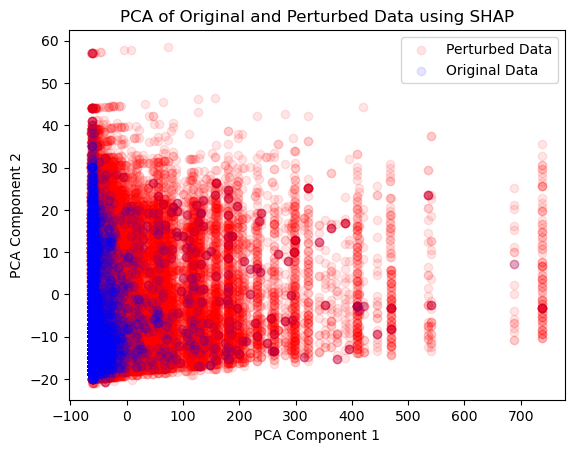

In [23]:
plot_2d_compas_pca(X_compas, SHAP, explain_n=1000)

## OOD Classifier Training
Rather than implementing the attack ourselves, we instead attempt to train an OOD classifier for both ALE and SHAP. Based on the F1 score reported, we can reuse the analysis in Figure 5 to determine how effective adversarial attacks would be.

In [59]:
# set seed
np.random.seed(42)

# create perturbed data for OOD classifier training
explain_n = 100
explain_indices = np.random.choice(X_compas.shape[0], explain_n, replace=False)

# only take numerical features
X_numerical = X_compas[["age", "priors_count", "length_of_stay"]].to_numpy()
dummy_f = lambda x: x
ale_explainer = ALE(dummy_f, X_numerical, verbose=False)
ale_explainer.explain()
shap_explainer = SHAP(dummy_f, X_numerical, verbose=False)
for i in range(explain_n):
    ale_explainer.explain_local(X_numerical[i, :])
    shap_explainer.explain_local(X_numerical[i, :])
X_queried_ale = ale_explainer.get_query_points()
X_queried_shap = shap_explainer.get_query_points()

# get perturbed as all queried that are not in original data
X_perturbed_ale = X_queried_ale # np.array([x for x in X_queried_ale if x.tolist() not in X_numerical.tolist()])
X_perturbed_shap = X_queried_shap # np.array([x for x in X_queried_shap if x.tolist() not in X_numerical.tolist()])

# create training and test data
X_ale = np.vstack((X_numerical, X_perturbed_ale))
y_ale = np.array([0]*X_numerical.shape[0] + [1]*X_perturbed_ale.shape[0])
X_shap = np.vstack((X_numerical, X_perturbed_shap))
y_shap = np.array([0]*X_numerical.shape[0] + [1]*X_perturbed_shap.shape[0])

/Users/dawsonren/Desktop/Experiments/ExplainableML/ale/tree_partitioning.py:290: UserWarning: generate_connected_delta_values: all features flat, splitting on first variable
  warnings.warn(


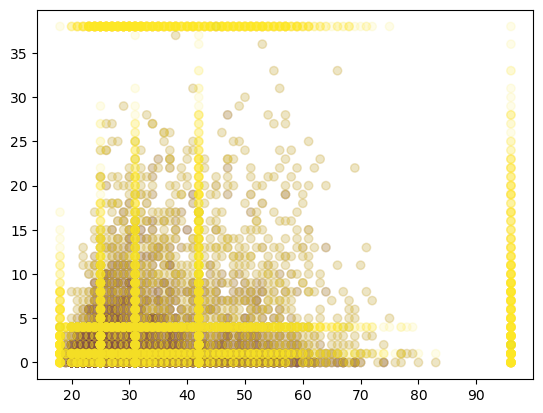

In [60]:
plt.scatter(X_ale[:, 0], X_ale[:, 1], c=y_ale, alpha=.1)

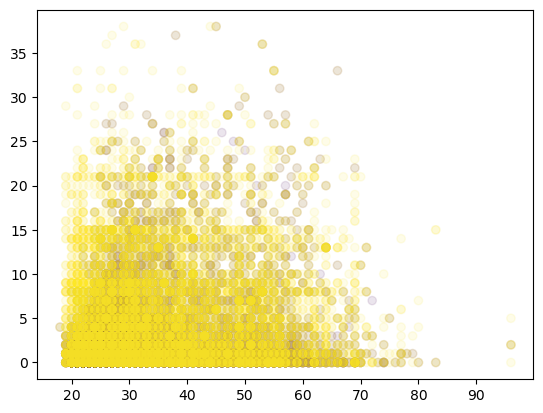

In [61]:
plt.scatter(X_shap[:, 0], X_shap[:, 1], c=y_shap, alpha=.1)

In [62]:
# train OOD classifiers

# split data into train and test
X_train_ale, X_test_ale, y_train_ale, y_test_ale = train_test_split(X_ale, y_ale, test_size=0.2)
X_train_shap, X_test_shap, y_train_shap, y_test_shap = train_test_split(X_shap, y_shap, test_size=0.2)

rf_ale = RandomForestClassifier(n_estimators=100)
rf_ale.fit(X_train_ale, y_train_ale)
print("ALE OOD Classifier")
print("Train F1:", f1_score(y_train_ale, rf_ale.predict(X_train_ale)))
print("Test F1:", f1_score(y_test_ale, rf_ale.predict(X_test_ale)))

rf_shap = RandomForestClassifier(n_estimators=100)
rf_shap.fit(X_train_shap, y_train_shap)
print("SHAP OOD Classifier")
print("Train F1:", f1_score(y_train_shap, rf_shap.predict(X_train_shap)))
print("Test F1:", f1_score(y_test_shap, rf_shap.predict(X_test_shap)))

ALE OOD Classifier
Train F1: 0.8978337928318235
Test F1: 0.7763819095477387
SHAP OOD Classifier
Train F1: 0.8889949868703748
Test F1: 0.7453567937438905
